# Finite Element Modal Analysis - Elevator Door

Author: Stellars Henson<br>
Approach: full Kirchhoff plate finite-element modal analysis of the elevator door,
solved with scikit-fem using Morley triangular elements on a tessellated 2-D
domain.  Clamped boundary conditions (zero displacement and zero normal
derivative on the frame) replace the simply-supported analytical baseline,
producing systematically higher frequencies that better reflect a real hinged
door bolted into a steel frame.  Computed mode shapes are visualised, frequencies
compared against the closed-form solution, and the FEM frequencies fed into a
refreshed audio synthesis.

## Approach

1. **Mesh** the steel panel (2.0 x 1.0 m, 2 mm) and the glass window (0.2 x 0.6 m,
   4 mm) as 2-D triangular meshes via `MeshTri.init_tensor`.
2. **Assemble** the biharmonic stiffness matrix from the Kirchhoff plate strain
   energy (Laplacian-squared + Poisson coupling term) and the consistent mass
   matrix, using the Morley non-conforming triangle (vertex value + edge-midpoint
   normal-derivative degrees of freedom).
3. **Apply clamped BC** by eliminating all boundary DOFs (both function values
   and normal derivatives).
4. **Solve** the generalised eigenproblem `K phi = lambda M phi` for the first
   ~30 modes via `scipy.sparse.linalg.eigsh`.
5. **Visualise** the mesh, the convergence vs analytical, and the first 12 mode
   shapes for each surface.
6. **Synthesise** an audio signal using the FEM mode frequencies as the
   spectral content; export WAV + MP3.

## Outputs

- `reports/figures/03-mesh-panel.png` - tessellated steel panel
- `reports/figures/03-mesh-window.png` - tessellated glass window
- `reports/figures/03-modes-vs-analytical.png` - FEM clamped vs analytical SS frequencies
- `reports/figures/03-mode-shapes-panel.png` - first 12 panel mode shapes
- `reports/figures/03-mode-shapes-window.png` - first 12 window mode shapes
- `reports/figures/03-fem-synth-spectrogram.png` - synthesised impact spectrogram
- `reports/figures/03-predicted-impact-audio.wav` - FEM-driven synthesis (lossless)
- `reports/figures/03-predicted-impact-audio.mp3` - FEM-driven synthesis (V2 VBR)

In [1]:
# Imports
from __future__ import annotations

from pathlib import Path
import subprocess

# Numerical / data
import numpy as np
import pandas as pd

# Plotting
import matplotlib.pyplot as plt
from matplotlib.tri import Triangulation
import seaborn as sns

# Rich console
from rich.console import Console
from rich.panel import Panel
from rich.table import Table

# FEM
from skfem import MeshTri, Basis, BilinearForm, ElementTriMorley, condense
from skfem.helpers import dd
from scipy.sparse.linalg import eigsh

# Audio I/O
from scipy.io import wavfile
from scipy.signal import spectrogram
import imageio_ffmpeg
from IPython.display import Audio, display

# Project library
from henryk_simulations.corridor.acoustics import (
    DEFAULT_ELEVATOR_DOOR,
    cavity_axial_frequency,
    plate_modes,
)

# Autoreload
%load_ext autoreload
%autoreload 2

console = Console()
sns.set_theme(style="whitegrid", context="notebook")

2026-05-15 15:00:20.350 | INFO     | henryk_simulations.config:<module>:40 - PROJ_ROOT path is: /home/lab/workspace/private/henryk/henryk-simulations


In [2]:
SEED = 42
np.random.seed(SEED)
rng = np.random.default_rng(SEED)

## Configuration

Mesh resolution, eigenproblem size, audio synthesis parameters.  `n_modes`
controls how many FEM modes feed the synthesis; the mesh density per surface
sets the FEM frequency resolution.

In [3]:
PARAMS = {
    "panel": {
        "a_m": DEFAULT_ELEVATOR_DOOR.panel.a_m,
        "b_m": DEFAULT_ELEVATOR_DOOR.panel.b_m,
        "thickness_m": DEFAULT_ELEVATOR_DOOR.panel.thickness_m,
        "E_Pa": DEFAULT_ELEVATOR_DOOR.panel.material.E,
        "nu": DEFAULT_ELEVATOR_DOOR.panel.material.nu,
        "rho_kg_m3": DEFAULT_ELEVATOR_DOOR.panel.material.rho,
        "mesh_nx": 33,    # 32 elements along the long edge
        "mesh_ny": 17,    # 16 elements along the short edge
    },
    "window": {
        "a_m": DEFAULT_ELEVATOR_DOOR.window.a_m,
        "b_m": DEFAULT_ELEVATOR_DOOR.window.b_m,
        "thickness_m": DEFAULT_ELEVATOR_DOOR.window.thickness_m,
        "E_Pa": DEFAULT_ELEVATOR_DOOR.window.material.E,
        "nu": DEFAULT_ELEVATOR_DOOR.window.material.nu,
        "rho_kg_m3": DEFAULT_ELEVATOR_DOOR.window.material.rho,
        "mesh_nx": 13,
        "mesh_ny": 25,
    },
    "fem": {
        "n_modes_panel": 30,
        "n_modes_window": 20,
        "n_modes_synth": 30,   # how many FEM modes per surface feed the audio synth
    },
    "audio": {
        "sample_rate_hz": 44100,
        "duration_s": 2.0,
        "lead_silence_s": 0.20,
        "peak_dbfs": -1.0,
        "ambient_dbfs": -55.0,
        "k_shape": 1.5,
        "tau_panel_s": 0.12,
        "tau_window_s": 0.09,
        "tau_cavity_s": 0.020,
        "contact_half_life_s": 0.0025,
        "contact_center_s": 0.0015,
        "panel_amp": 0.55,
        "window_amp": 0.85,
        "cavity_amp": 0.55,
        "contact_amp": 0.45,
        "strike_gain_2x": 2.0,
    },
    "paths": {
        "fig_dir": Path("..") / "reports" / "figures",
    },
}

FIG_DIR = PARAMS["paths"]["fig_dir"]
FIG_DIR.mkdir(parents=True, exist_ok=True)

table = Table(show_header=False, box=None, padding=(0, 2))
table.add_column("k", style="bold cyan", no_wrap=True)
table.add_column("v")
for section, items in PARAMS.items():
    table.add_row(f"[bold magenta]{section}[/bold magenta]", "")
    for k, v in items.items():
        table.add_row(f"  {k}", f"[white]{v}[/white]")
console.print(Panel(table, title="[bold green]PARAMS[/bold green]", border_style="green"))

╭──────────────────────────────────────────────────── PARAMS ─────────────────────────────────────────────────────╮
│   panel                                                                                                         │
│     a_m                    2.0                                                                                  │
│     b_m                    1.0                                                                                  │
│     thickness_m            0.002                                                                                │
│     E_Pa                   200000000000.0                                                                       │
│     nu                     0.3                                                                                  │
│     rho_kg_m3              7850                                                                                 │
│     mesh_nx                33                                                                                   │
│     mesh_ny                17                                                                                   │
│   window                                                                                                        │
│     a_m                    0.2                                                                                  │
│     b_m                    0.6                                                                                  │
│     thickness_m            0.004                                                                                │
│     E_Pa                   70000000000.0                                                                        │
│     nu                     0.22                                                                                 │
│     rho_kg_m3              2500                                                                                 │
│     mesh_nx                13                                                                                   │
│     mesh_ny                25                                                                                   │
│   fem                                                                                                           │
│     n_modes_panel          30                                                                                   │
│     n_modes_window         20                                                                                   │
│     n_modes_synth          30                                                                                   │
│   audio                                                                                                         │
│     sample_rate_hz         44100                                                                                │
│     duration_s             2.0                                                                                  │
│     lead_silence_s         0.2                                                                                  │
│     peak_dbfs              -1.0                                                                                 │
│     ambient_dbfs           -55.0                                                                                │
│     k_shape                1.5                                                                                  │
│     tau_panel_s            0.12                                                                                 │
│     tau_window_s           0.09                                                                                 │
│     tau_cavity_s           0.02                                                                                 │
│     contact_half_life_s    0.0025                                                                               │
│     contact_center_s       0.0015                     

## Kirchhoff Plate Theory

A thin elastic plate of thickness $h$, density $\rho$, Young's modulus $E$, and
Poisson ratio $\nu$ vibrates according to the Kirchhoff-Love plate equation:

$$D \, \nabla^4 w + \rho h \, \ddot{w} = 0$$

with bending stiffness $D = E h^3 / [12(1 - \nu^2)]$ and out-of-plane
displacement $w(x, y, t)$.  Separation of variables $w = \phi(x,y) e^{i\omega t}$
yields the eigenproblem

$$D \, \nabla^4 \phi = \rho h \, \omega^2 \phi$$

The strain energy is

$$U = \frac{D}{2} \int_{\Omega} \left[ (\nabla^2 w)^2 + 2(1-\nu)\left(w_{xy}^2 - w_{xx} w_{yy}\right) \right] dA$$

The FEM weak form uses $U$ as the bilinear form for the stiffness matrix and
$\int w \, v \, dA$ for the mass matrix.  Morley non-conforming triangles
satisfy the $H^2$-continuity requirement in a discrete sense: nodal values at
vertices, normal derivatives at edge midpoints.

**Boundary conditions**.  Clamped (built-in) edges: $w = 0$ and
$\partial w / \partial n = 0$ on $\partial \Omega$.  This eliminates BOTH
DOF types on every boundary edge - tighter constraint than simply-supported
($w=0$, free rotation), giving systematically higher frequencies.

In [4]:
def assemble_plate_fem(a_m, b_m, thickness_m, E_Pa, nu, rho_kg_m3, nx, ny):
    """Assemble Kirchhoff plate biharmonic stiffness + mass via Morley FEM.

    Returns (mesh, basis, K, M, D_stiff, sigma_m) where K, M are sparse and
    D_stiff = bending stiffness, sigma_m = surface mass density.
    """
    D_stiff = E_Pa * thickness_m**3 / (12 * (1 - nu**2))
    sigma_m = rho_kg_m3 * thickness_m

    mesh = MeshTri.init_tensor(np.linspace(0, a_m, nx), np.linspace(0, b_m, ny))
    basis = Basis(mesh, ElementTriMorley())

    @BilinearForm
    def biharm(u, v, w):
        lap_u = dd(u)[0, 0] + dd(u)[1, 1]
        lap_v = dd(v)[0, 0] + dd(v)[1, 1]
        return (lap_u * lap_v
                + (1 - nu) * (2 * dd(u)[0, 1] * dd(v)[0, 1]
                              - dd(u)[0, 0] * dd(v)[1, 1]
                              - dd(u)[1, 1] * dd(v)[0, 0]))

    @BilinearForm
    def mass_form(u, v, w):
        return u * v

    K = biharm.assemble(basis)
    M = mass_form.assemble(basis)
    return mesh, basis, K, M, D_stiff, sigma_m


def solve_clamped_modes(K, M, basis, n_modes, D_stiff, sigma_m):
    """Solve generalised eigenproblem with clamped boundary (all bdry DOFs = 0).

    Returns (frequencies_Hz, eigenvectors_full, interior_dofs).
    """
    D_bdry = basis.get_dofs()
    K_c, M_c = condense(K, M, D=D_bdry, expand=False)
    vals, vecs = eigsh(K_c, M=M_c, k=n_modes, which="SM", tol=1e-8)
    order = np.argsort(vals)
    vals = vals[order]
    vecs = vecs[:, order]
    omega_sq = vals * D_stiff / sigma_m
    freqs_hz = np.sqrt(np.maximum(omega_sq, 0)) / (2 * np.pi)

    # Expand interior eigenvectors back to full DOF vector (zero on boundary)
    bdry_idx = D_bdry.flatten()
    all_idx = np.arange(basis.N)
    interior_idx = np.setdiff1d(all_idx, bdry_idx)
    full_vecs = np.zeros((basis.N, vecs.shape[1]))
    full_vecs[interior_idx, :] = vecs
    return freqs_hz, full_vecs, interior_idx

## Panel - Tessellation and Modes

Steel panel: 2.0 x 1.0 m, 2 mm thick.  Tensor-product triangular mesh with
32 x 16 = 1024 elements (2048 triangles).  Morley DOFs: vertex values + edge
normal derivatives.  Clamped boundary on all four edges.

In [5]:
p = PARAMS["panel"]
mesh_p, basis_p, K_p, M_p, D_p, sigma_p = assemble_plate_fem(
    p["a_m"], p["b_m"], p["thickness_m"], p["E_Pa"], p["nu"], p["rho_kg_m3"],
    p["mesh_nx"], p["mesh_ny"],
)
freqs_p, vecs_p, interior_p = solve_clamped_modes(
    K_p, M_p, basis_p, PARAMS["fem"]["n_modes_panel"], D_p, sigma_p,
)
console.print(f"[cyan]Panel FEM:[/cyan] {mesh_p.nelements} elements, "
              f"{basis_p.N} DOFs, {len(basis_p.get_dofs().flatten())} boundary DOFs")
console.print(f"[cyan]D = {D_p:.2f} N*m, sigma = {sigma_p:.3f} kg/m^2[/cyan]")
console.print(f"[bold green]first 6 clamped frequencies:[/bold green] "
              + ", ".join(f"{f:.2f} Hz" for f in freqs_p[:6]))

Panel FEM: 1024 elements, 2145 DOFs, 192 boundary DOFs

D = 146.52 N*m, sigma = 15.700 kg/m^2

first 6 clamped frequencies: 11.54 Hz, 14.89 Hz, 20.80 Hz, 28.92 Hz, 29.07 Hz, 32.09 Hz

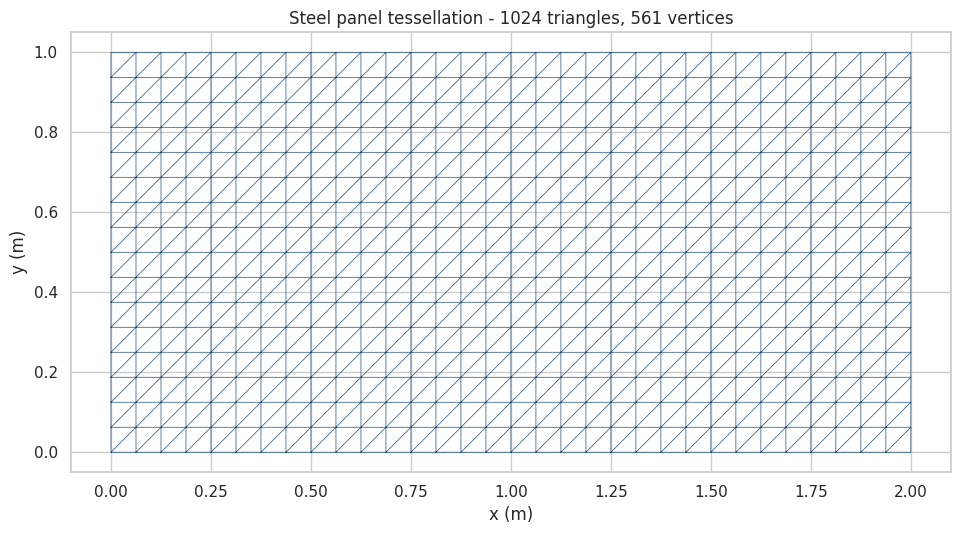

In [6]:
# Panel mesh visualisation
fig, ax = plt.subplots(figsize=(11, 5.5))
ax.triplot(mesh_p.p[0], mesh_p.p[1], mesh_p.t.T, color="#1f4e7a", lw=0.5)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Steel panel tessellation - {mesh_p.nelements} triangles, {mesh_p.nvertices} vertices")
fig.tight_layout()
fig.savefig(FIG_DIR / "03-mesh-panel.png", dpi=140, bbox_inches="tight")
plt.show()

## Glass Window - Tessellation and Modes

Glass window: 0.2 x 0.6 m, 4 mm thick. E = 70 GPa, nu = 0.22, rho = 2500 kg/m^3.
Mesh: 12 x 24 = 288 elements.  Clamped on all four edges (the frame holds the
glass).

Window FEM: 576 elements, 1225 DOFs, 144 boundary DOFs

D = 392.32 N*m, sigma = 10.000 kg/m^2

first 6 clamped frequencies: 530.78 Hz, 591.24 Hz, 701.35 Hz, 864.02 Hz, 1076.25 Hz, 1317.07 Hz

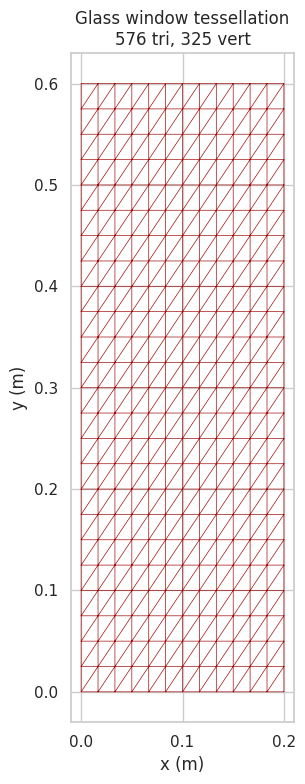

In [7]:
w = PARAMS["window"]
mesh_w, basis_w, K_w, M_w, D_w, sigma_w = assemble_plate_fem(
    w["a_m"], w["b_m"], w["thickness_m"], w["E_Pa"], w["nu"], w["rho_kg_m3"],
    w["mesh_nx"], w["mesh_ny"],
)
freqs_w, vecs_w, interior_w = solve_clamped_modes(
    K_w, M_w, basis_w, PARAMS["fem"]["n_modes_window"], D_w, sigma_w,
)
console.print(f"[cyan]Window FEM:[/cyan] {mesh_w.nelements} elements, "
              f"{basis_w.N} DOFs, {len(basis_w.get_dofs().flatten())} boundary DOFs")
console.print(f"[cyan]D = {D_w:.2f} N*m, sigma = {sigma_w:.3f} kg/m^2[/cyan]")
console.print(f"[bold green]first 6 clamped frequencies:[/bold green] "
              + ", ".join(f"{f:.2f} Hz" for f in freqs_w[:6]))

# Window mesh plot
fig, ax = plt.subplots(figsize=(4, 8))
ax.triplot(mesh_w.p[0], mesh_w.p[1], mesh_w.t.T, color="#a01010", lw=0.5)
ax.set_aspect("equal")
ax.set_xlabel("x (m)")
ax.set_ylabel("y (m)")
ax.set_title(f"Glass window tessellation\n{mesh_w.nelements} tri, {mesh_w.nvertices} vert")
fig.tight_layout()
fig.savefig(FIG_DIR / "03-mesh-window.png", dpi=140, bbox_inches="tight")
plt.show()

## FEM Clamped vs Analytical Simply-Supported

The clamped boundary stiffens the plate compared with simply-supported, so all
FEM-computed frequencies should sit above their analytical counterparts.  The
ratio depends on mode index but typically falls in the 1.5 - 2.0 range for the
fundamental and converges toward 1.0 for high-order modes.  This plot shows
both spectra side by side.

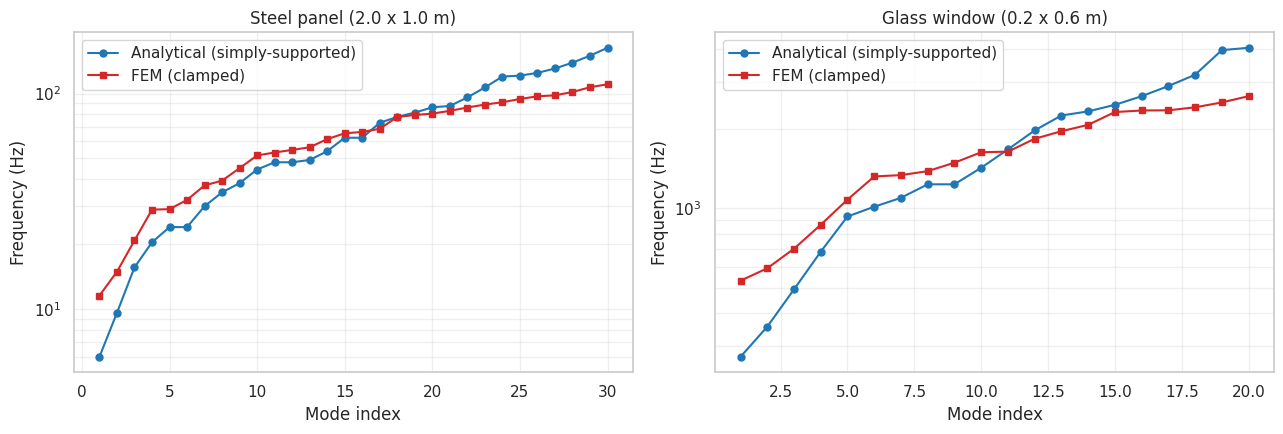

                         Clamped / simply-supported frequency ratio                         
┏━━━━━━┳━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━┳━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┳━━━━━━━┓
┃ Mode ┃ Panel SS (Hz) ┃ Panel FEM (Hz) ┃ Ratio ┃ Window SS (Hz) ┃ Window FEM (Hz) ┃ Ratio ┃
┡━━━━━━╇━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━╇━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━╇━━━━━━━┩
│    1 │          6.00 │          11.54 │ 1.923 │         273.30 │          530.78 │ 1.942 │
│    2 │          9.60 │          14.89 │ 1.552 │         355.29 │          591.24 │ 1.664 │
│    3 │         15.60 │          20.80 │ 1.334 │         491.94 │          701.35 │ 1.426 │
│    4 │         20.39 │          28.92 │ 1.418 │         683.25 │          864.02 │ 1.265 │
│    5 │         23.99 │          29.07 │ 1.212 │         929.22 │         1076.25 │ 1.158 │
│    6 │         23.99 │          32.09 │ 1.337 │        1011.21 │         1317.07 │ 1.302 │
│    7 │         29.99 │          37.48 │ 1.250 │        1093.20 │         1332.45 │ 1.219 │
│    8 │         34.79 │          39.43 │ 1.133 │        1229.85 │         1379.34 │ 1.122 │
│    9 │         38.39 │          45.07 │ 1.174 │        1229.85 │         1484.95 │ 1.207 │
│   10 │         44.39 │          51.61 │ 1.163 │        1421.16 │         1626.34 │ 1.144 │
└──────┴───────────────┴────────────────┴───────┴────────────────┴─────────────────┴───────┘

In [8]:
# Analytical SS reference
def ss_modes(a, b, D_stiff, sigma_m, m_max=6, n_max=6):
    out = []
    for mm in range(1, m_max + 1):
        for nn in range(1, n_max + 1):
            lam = (mm * np.pi / a) ** 2 + (nn * np.pi / b) ** 2
            f = (1 / (2 * np.pi)) * np.sqrt(D_stiff / sigma_m) * lam
            out.append(f)
    return np.sort(out)

ss_p = ss_modes(p["a_m"], p["b_m"], D_p, sigma_p)
ss_w = ss_modes(w["a_m"], w["b_m"], D_w, sigma_w)

# Comparison plot - two panels
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

ax = axes[0]
n_p = min(len(freqs_p), len(ss_p))
ax.plot(range(1, n_p + 1), ss_p[:n_p], "o-", color="#1f77b4", label="Analytical (simply-supported)", markersize=5)
ax.plot(range(1, n_p + 1), freqs_p[:n_p], "s-", color="#d62728", label="FEM (clamped)", markersize=5)
ax.set_xlabel("Mode index")
ax.set_ylabel("Frequency (Hz)")
ax.set_title(f"Steel panel ({p['a_m']:.1f} x {p['b_m']:.1f} m)")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

ax = axes[1]
n_w = min(len(freqs_w), len(ss_w))
ax.plot(range(1, n_w + 1), ss_w[:n_w], "o-", color="#1f77b4", label="Analytical (simply-supported)", markersize=5)
ax.plot(range(1, n_w + 1), freqs_w[:n_w], "s-", color="#d62728", label="FEM (clamped)", markersize=5)
ax.set_xlabel("Mode index")
ax.set_ylabel("Frequency (Hz)")
ax.set_title(f"Glass window ({w['a_m']:.1f} x {w['b_m']:.1f} m)")
ax.set_yscale("log")
ax.grid(True, which="both", alpha=0.3)
ax.legend()

fig.tight_layout()
fig.savefig(FIG_DIR / "03-modes-vs-analytical.png", dpi=140, bbox_inches="tight")
plt.show()

# Ratio table
ratios_p = freqs_p[:n_p] / ss_p[:n_p]
ratios_w = freqs_w[:n_w] / ss_w[:n_w]

t = Table(title="[bold]Clamped / simply-supported frequency ratio[/bold]", show_header=True, header_style="bold cyan")
t.add_column("Mode", justify="right")
t.add_column("Panel SS (Hz)", justify="right")
t.add_column("Panel FEM (Hz)", justify="right")
t.add_column("Ratio", justify="right", style="bold yellow")
t.add_column("Window SS (Hz)", justify="right")
t.add_column("Window FEM (Hz)", justify="right")
t.add_column("Ratio", justify="right", style="bold yellow")
for i in range(min(10, n_p, n_w)):
    t.add_row(
        str(i + 1),
        f"{ss_p[i]:.2f}", f"{freqs_p[i]:.2f}", f"{ratios_p[i]:.3f}",
        f"{ss_w[i]:.2f}", f"{freqs_w[i]:.2f}", f"{ratios_w[i]:.3f}",
    )
console.print(t)

## Mode Shapes

The Morley element stores function values at vertices and normal derivatives at
edge midpoints.  For visualisation we keep only the vertex values (the function
values of the mode shape), giving a continuous piecewise-linear interpolation
on the underlying triangulation.  Below: first 12 mode shapes for each surface,
arranged in a 3 x 4 grid.

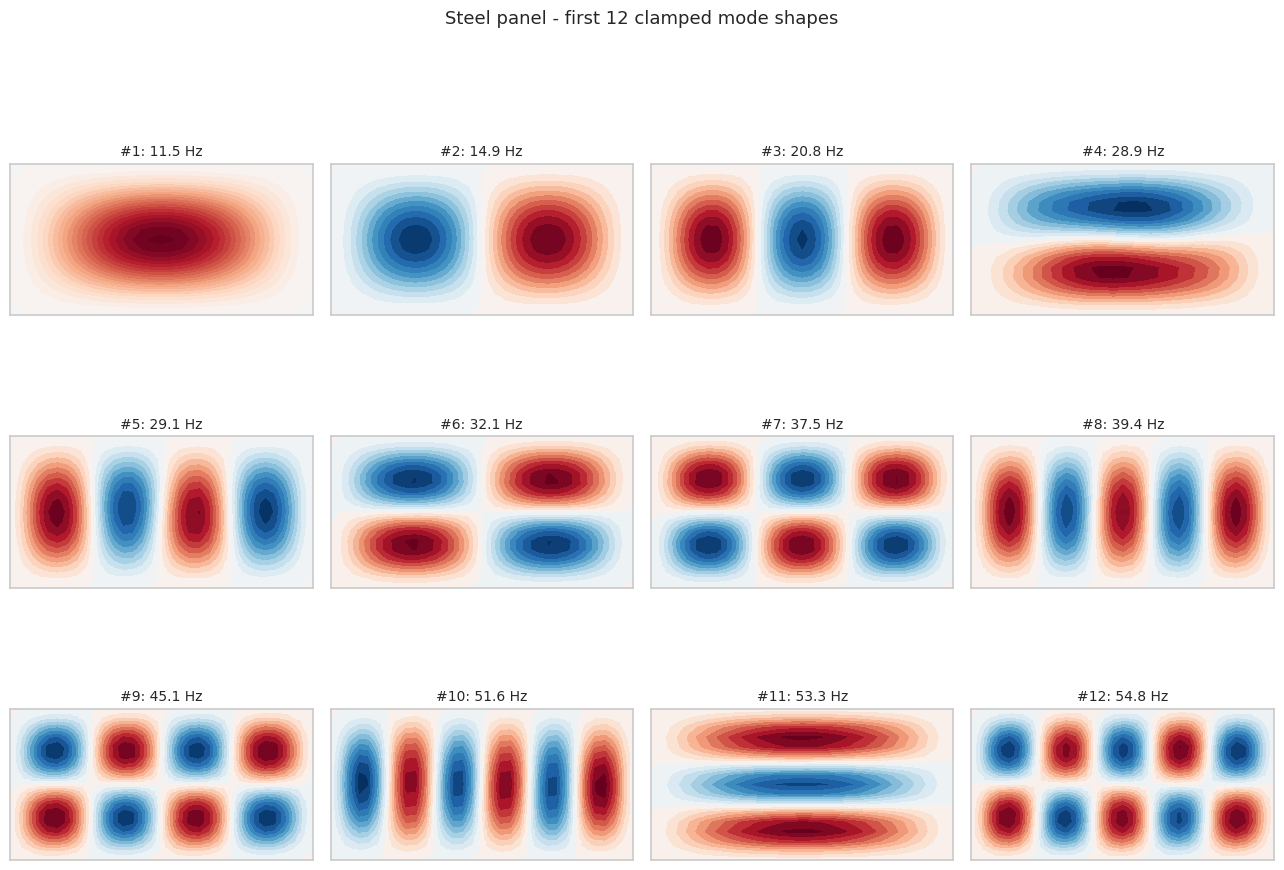

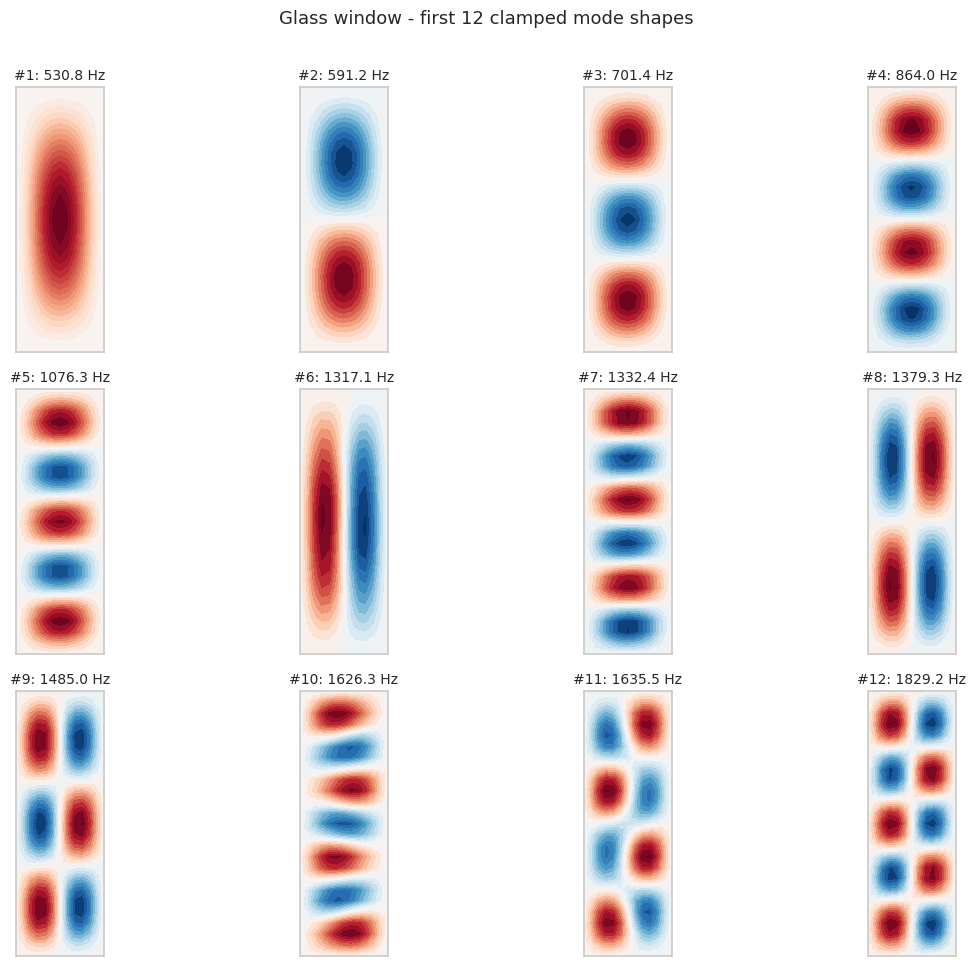

In [9]:
def plot_mode_shapes(mesh, basis, vecs, freqs, title, n_show=12, ncols=4):
    """Plot first n_show mode shapes as filled contour panels.

    Morley basis = vertex values (n_vertices) + edge normal derivatives.  We
    extract the first n_vertices entries (vertex values) of each eigenvector.
    """
    nrows = (n_show + ncols - 1) // ncols
    fig, axes = plt.subplots(nrows, ncols, figsize=(13, 3.2 * nrows))
    axes = axes.flatten() if nrows > 1 else [axes] if ncols == 1 else axes
    tri = Triangulation(mesh.p[0], mesh.p[1], mesh.t.T)
    n_vert = mesh.nvertices
    for idx in range(n_show):
        ax = axes[idx]
        # Vertex values are the first n_vertices DOFs in Morley layout
        u = vecs[:n_vert, idx]
        # Normalise sign so the largest-magnitude value is positive
        if np.abs(u.min()) > np.abs(u.max()):
            u = -u
        vmax = np.max(np.abs(u))
        cf = ax.tricontourf(tri, u, levels=21, cmap="RdBu_r", vmin=-vmax, vmax=vmax)
        ax.set_aspect("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"#{idx + 1}: {freqs[idx]:.1f} Hz", fontsize=10)
    for ax in axes[n_show:]:
        ax.axis("off")
    fig.suptitle(title, fontsize=13, y=1.005)
    fig.tight_layout()
    return fig

fig_p = plot_mode_shapes(mesh_p, basis_p, vecs_p, freqs_p,
                          "Steel panel - first 12 clamped mode shapes")
fig_p.savefig(FIG_DIR / "03-mode-shapes-panel.png", dpi=140, bbox_inches="tight")
plt.show()

fig_w = plot_mode_shapes(mesh_w, basis_w, vecs_w, freqs_w,
                          "Glass window - first 12 clamped mode shapes",
                          ncols=4)
fig_w.savefig(FIG_DIR / "03-mode-shapes-window.png", dpi=140, bbox_inches="tight")
plt.show()

## FEM-Driven Audio Synthesis

Replace the analytical Kirchhoff frequencies from notebook 02 with the FEM
clamped frequencies and resynthesise.  Same gamma-envelope formulation
(`k = 1.5`, sharp attack, per-family time constants), same 2x strike gain,
same -1 dBFS peak normalisation.  The audible difference vs notebook 02:
clamped frequencies are 1.5-2x higher, so the perceived pitch of the impact
shifts upward; the sound feels tighter and more "metallic-doored" rather than
sub-bass-dominated.

In [10]:
def gamma_envelope(t, tau, k=1.5):
    out = np.zeros_like(t, dtype=float)
    mask = t > 0
    ts = t[mask]
    if k > 1:
        peak_t = (k - 1.0) * tau
        peak_val = (peak_t / tau) ** (k - 1.0) * np.exp(-(k - 1.0))
    else:
        peak_val = 1.0
    out[mask] = (ts / tau) ** (k - 1.0) * np.exp(-ts / tau) / peak_val
    return out


a_cfg = PARAMS["audio"]
sr = a_cfg["sample_rate_hz"]
n_samples = int(sr * a_cfg["duration_s"])
t = np.arange(n_samples) / sr
lead = a_cfg["lead_silence_s"]
t_rel = t - lead

k_shape = a_cfg["k_shape"]
n_modes_synth = PARAMS["fem"]["n_modes_synth"]

# Panel modes (FEM clamped)
strike = np.zeros(n_samples)
panel_freqs_used = freqs_p[:n_modes_synth]
for i, f in enumerate(panel_freqs_used):
    env = gamma_envelope(t_rel, a_cfg["tau_panel_s"], k=k_shape)
    phi = rng.uniform(0, 2 * np.pi)
    weight = (panel_freqs_used[0] / f) ** 0.3
    strike += a_cfg["panel_amp"] * weight * env * np.sin(2 * np.pi * f * t_rel + phi)

# Window modes (FEM clamped)
window_freqs_used = freqs_w[:min(n_modes_synth, len(freqs_w))]
f0_w = window_freqs_used[0]
for f in window_freqs_used:
    env = gamma_envelope(t_rel, a_cfg["tau_window_s"], k=k_shape)
    phi = rng.uniform(0, 2 * np.pi)
    weight = (f0_w / f) ** 0.7
    strike += a_cfg["window_amp"] * weight * env * np.sin(2 * np.pi * f * t_rel + phi)

# Cavity mode (analytical, unchanged - half-wave air column)
f_cav = cavity_axial_frequency(DEFAULT_ELEVATOR_DOOR.cavity_gap_m)
env_c = gamma_envelope(t_rel, a_cfg["tau_cavity_s"], k=k_shape)
strike += a_cfg["cavity_amp"] * env_c * np.sin(2 * np.pi * f_cav * t_rel)

# Broadband contact burst
ct_center = a_cfg["contact_center_s"]
ct_hl = a_cfg["contact_half_life_s"]
contact_env = np.exp(-((t_rel - ct_center) ** 2) / (2 * ct_hl ** 2)) * (t_rel >= 0)
strike += a_cfg["contact_amp"] * rng.standard_normal(n_samples) * contact_env

# 2x strike gain + ambient + peak normalise
strike *= a_cfg["strike_gain_2x"]
ambient = rng.standard_normal(n_samples) * 10 ** (a_cfg["ambient_dbfs"] / 20)
signal = strike + ambient
peak_val = np.max(np.abs(signal))
target = 10 ** (a_cfg["peak_dbfs"] / 20)
signal = signal / peak_val * target

# Diagnostics
strike_seg = signal[int(sr * lead): int(sr * (lead + 0.5))]
ambient_seg = signal[: int(sr * lead)]
strike_rms_db = 20 * np.log10(max(np.sqrt(np.mean(strike_seg ** 2)), 1e-9))
ambient_rms_db = 20 * np.log10(max(np.sqrt(np.mean(ambient_seg ** 2)), 1e-9))
n_clipped = int(np.sum(np.abs(signal) >= 0.99999))

diag = Table(show_header=False, box=None, padding=(0, 2))
diag.add_column("k", style="bold cyan")
diag.add_column("v")
diag.add_row("Panel modes (FEM)", f"{len(panel_freqs_used)}")
diag.add_row("Window modes (FEM)", f"{len(window_freqs_used)}")
diag.add_row("Cavity (analytical)", "1")
diag.add_row("Total modes", f"{len(panel_freqs_used) + len(window_freqs_used) + 1}")
diag.add_row("Peak", f"{20*np.log10(max(np.max(np.abs(signal)), 1e-9)):.2f} dBFS")
diag.add_row("Strike RMS", f"{strike_rms_db:.1f} dBFS")
diag.add_row("Ambient RMS", f"{ambient_rms_db:.1f} dBFS")
diag.add_row("SNR", f"[bold green]{strike_rms_db - ambient_rms_db:.1f} dB[/bold green]")
diag.add_row("Clipped samples", f"[{'red' if n_clipped else 'green'}]{n_clipped}[/]")
console.print(Panel(diag, title="[bold]FEM-driven synthesis diagnostics[/bold]", border_style="cyan"))

╭─────────────────────────────────────── FEM-driven synthesis diagnostics ────────────────────────────────────────╮
│   Panel modes (FEM)      30                                                                                     │
│   Window modes (FEM)     20                                                                                     │
│   Cavity (analytical)    1                                                                                      │
│   Total modes            51                                                                                     │
│   Peak                   -1.00 dBFS                                                                             │
│   Strike RMS             -15.9 dBFS                                                                             │
│   Ambient RMS            -77.9 dBFS                                                                             │
│   SNR                    61.9 dB                                                                                │
│   Clipped samples        0                                                                                      │
╰─────────────────────────────────────────────────────────────────────────────────────────────────────────────────╯

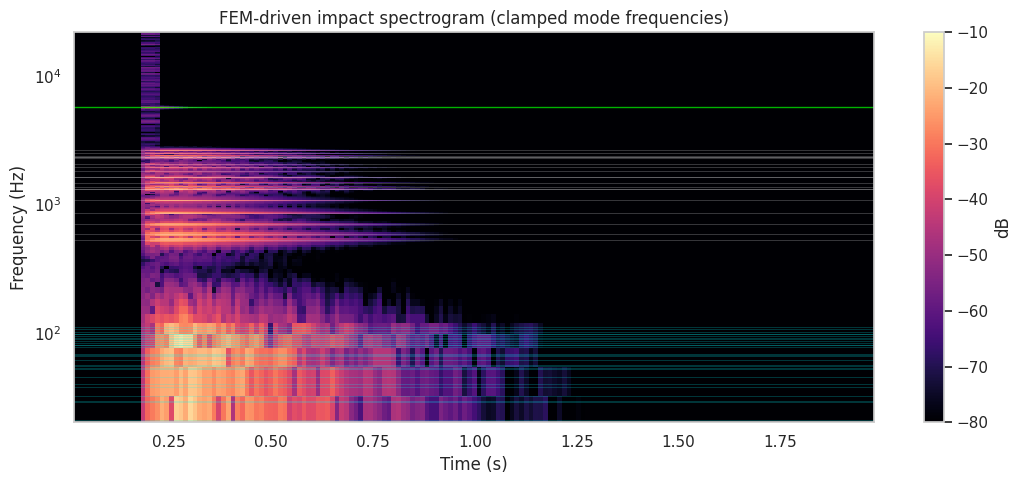

In [11]:
# Spectrogram
f_spec, t_spec, Sxx = spectrogram(signal, fs=sr, nperseg=2048, noverlap=1536, scaling="spectrum")
Sxx_db = 10 * np.log10(np.maximum(Sxx, 1e-12))

fig, ax = plt.subplots(figsize=(11, 5))
mesh_im = ax.pcolormesh(t_spec, f_spec, Sxx_db, shading="auto", cmap="magma", vmin=-80, vmax=-10)
ax.set_yscale("log")
ax.set_ylim(20, sr / 2)
ax.set_xlabel("Time (s)")
ax.set_ylabel("Frequency (Hz)")
ax.set_title("FEM-driven impact spectrogram (clamped mode frequencies)")
fig.colorbar(mesh_im, ax=ax, label="dB")

# Overlay FEM mode lines
for f in panel_freqs_used:
    ax.axhline(f, color="cyan", alpha=0.3, lw=0.5)
for f in window_freqs_used:
    ax.axhline(f, color="white", alpha=0.3, lw=0.5)
ax.axhline(f_cav, color="lime", alpha=0.7, lw=1.0)

fig.tight_layout()
fig.savefig(FIG_DIR / "03-fem-synth-spectrogram.png", dpi=140, bbox_inches="tight")
plt.show()

## Export

In [12]:
wav_path = FIG_DIR / "03-predicted-impact-audio.wav"
mp3_path = FIG_DIR / "03-predicted-impact-audio.mp3"

audio_int16 = np.int16(signal * 32767)
wavfile.write(str(wav_path), sr, audio_int16)
console.print(f"[green]wrote[/green] {wav_path} ({wav_path.stat().st_size} bytes)")

ffmpeg = imageio_ffmpeg.get_ffmpeg_exe()
subprocess.run(
    [ffmpeg, "-y", "-loglevel", "error", "-i", str(wav_path),
     "-codec:a", "libmp3lame", "-qscale:a", "2", str(mp3_path)],
    check=True,
)
console.print(f"[green]wrote[/green] {mp3_path} ({mp3_path.stat().st_size} bytes)")

display(Audio(str(wav_path), rate=sr))

wrote ../reports/figures/03-predicted-impact-audio.wav (176444 bytes)

wrote ../reports/figures/03-predicted-impact-audio.mp3 (23575 bytes)